In [58]:
!pip install pmdarima --quiet

In [59]:
import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go


# time-series
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose


# Stationarity
from statsmodels.tsa.stattools import adfuller

# model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Cross Validation
import itertools
from sklearn.model_selection import TimeSeriesSplit
from pmdarima import ARIMA as PmdarimaARIMA, auto_arima
from pmdarima.model_selection import RollingForecastCV, cross_val_score

# Parameter Tuning
from sklearn.model_selection import ParameterGrid

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

In [60]:
ffill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/ffill_df_for_modeling_713.xlsx',
                         parse_dates = True).set_index('Datetime')

bfill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/bfill_df_for_modeling_713.xlsx',
                         parse_dates = True).set_index('Datetime')

interpolation_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/interpolation_df_for_modeling_713.xlsx',
                                 parse_dates = True).set_index('Datetime')



target_feature = 'IN, COD'

for_validation = 160
for_test = 160

# Setting target feature

ffill_train_target = ffill_df[target_feature].iloc[:-for_validation-for_test]
ffill_train_inputs = ffill_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

ffill_val_target = ffill_df[target_feature].iloc[-for_validation-for_test:-for_test]
ffill_val_inputs = ffill_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

ffill_test_target = ffill_df[target_feature].iloc[-for_test:]
ffill_test_inputs = ffill_df.drop(columns=target_feature).iloc[-for_test:]


bfill_train_target = bfill_df[target_feature].iloc[:-for_validation-for_test]
bfill_train_inputs = bfill_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

bfill_val_target = bfill_df[target_feature].iloc[-for_validation-for_test:-for_test]
bfill_val_inputs = bfill_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

bfill_test_target = bfill_df[target_feature].iloc[-for_test:]
bfill_test_inputs = bfill_df.drop(columns=target_feature).iloc[-for_test:]


interpolation_train_target = interpolation_df[target_feature].iloc[:-for_validation-for_test]
interpolation_train_inputs = interpolation_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

interpolation_val_target = interpolation_df[target_feature].iloc[-for_validation-for_test:-for_test]
interpolation_val_inputs = interpolation_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

interpolation_test_target = interpolation_df[target_feature].iloc[-for_test:]
interpolation_test_inputs = interpolation_df.drop(columns=target_feature).iloc[-for_test:]

In [61]:
print(f"ffill_train_target shape: {ffill_train_target.shape}")
print(f"ffill_val_target shape: {ffill_val_target.shape}")
print(f"ffill_test_target shape: {ffill_test_target.shape}")

print(f"bfill_train_target shape: {bfill_train_target.shape}")
print(f"bfill_val_target shape: {bfill_val_target.shape}")
print(f"bfill_test_target shape: {bfill_test_target.shape}")

print(f"interpolation_train_target shape: {interpolation_train_target.shape}")
print(f"interpolation_val_target shape: {interpolation_val_target.shape}")
print(f"interpolation_test_target shape: {interpolation_test_target.shape}")

ffill_train_target shape: (858,)
ffill_val_target shape: (160,)
ffill_test_target shape: (160,)
bfill_train_target shape: (855,)
bfill_val_target shape: (160,)
bfill_test_target shape: (160,)
interpolation_train_target shape: (858,)
interpolation_val_target shape: (160,)
interpolation_test_target shape: (160,)


# Modeling

- Univarite Forecasting (Holt-Winters, ARIMA, and SARIMA)
- Forecasting with Exogenous Features (SARIMAX)

## Holt-Winters

In [68]:
# Alpha

def exp_tuning_alpha(n_splits: int,
                     alphas: list[float],
                     df: pd.DataFrame):

  tscv = TimeSeriesSplit(n_splits=n_splits)
  error_list = []

  for alpha in alphas:

    errors = []

    for train_index, test_index in tscv.split(df):

      train_data = df.iloc[train_index]
      test_data = df.iloc[test_index]

      model = ExponentialSmoothing(train_data,
                                   trend='add',
                                   seasonal='add',
                                   seasonal_periods=30,
                                   freq='D')\
                                   .fit(smoothing_level=alpha)

      predictions = model.forecast(len(test_data))
      rmse = root_mean_squared_error(test_data, predictions)
      errors.append(rmse)

    error_list.append({'Alpha': alpha, 'RMSE': np.mean(errors)})

  return pd.DataFrame(error_list)



def plot_error_cv_alpha(df: pd.DataFrame,
                  title: str):
  fig = px.line(df,
                x='Alpha',
                y='RMSE',
                title=title)
  fig.update_layout(template='simple_white', font=dict(size=18),
                    title_text =title,
                    width=800,
                    title_x = 0.5,
                    height = 400)
  fig.show()

# Beta

def exp_tuning_beta(n_splits: int,
                             betas: list[float],
                             df: pd.DataFrame):

  tscv = TimeSeriesSplit(n_splits=n_splits)
  error_list = []

  for beta in betas:

    errors = []

    for train_index, test_index in tscv.split(df):

      train_data = df.iloc[train_index]
      test_data = df.iloc[test_index]

      model = ExponentialSmoothing(train_data,
                                   trend='add',
                                   seasonal='add',
                                   seasonal_periods=30,
                                   freq='D')\
                                   .fit(smoothing_level=0.8, smoothing_trend=beta)

      predictions = model.forecast(len(test_data))
      rmse = root_mean_squared_error(test_data, predictions)
      errors.append(rmse)

    error_list.append({'Beta': beta, 'RMSE': np.mean(errors)})

  return pd.DataFrame(error_list)

def plot_error_cv_beta(df: pd.DataFrame,
                  title: str):

  fig = px.line(df,
                x='Beta',
                y='RMSE',
                title=title)
  fig.update_layout(template='simple_white', font=dict(size=18),
                    title_text =title,
                    width=800,
                    title_x = 0.5,
                    height = 400)
  fig.show()

 # Gama

def exp_tuning_gamma(n_splits: int,
                             gammas: list[float],
                             df: pd.DataFrame):

  tscv = TimeSeriesSplit(n_splits=n_splits)
  error_list = []

  for gamma  in gammas:

    errors = []

    for train_index, test_index in tscv.split(df):

      train_data = df.iloc[train_index]
      test_data = df.iloc[test_index]

      model = ExponentialSmoothing(train_data,
                                   trend='add',
                                   seasonal='add',
                                   seasonal_periods=30,
                                   freq='D')\
                                   .fit(smoothing_level=0.8, smoothing_trend=0.1, smoothing_seasonal = gamma)

      predictions = model.forecast(len(test_data))
      rmse = root_mean_squared_error(test_data, predictions)
      errors.append(rmse)

    error_list.append({'Gamma': gamma, 'RMSE': np.mean(errors)})

  return pd.DataFrame(error_list)

def plot_error_cv_gamma(df: pd.DataFrame,
                  title: str):

  fig = px.line(df,
                x='Gamma',
                y='RMSE',
                title=title)
  fig.update_layout(template='simple_white', font=dict(size=18),
                    title_text =title,
                    width=800,
                    title_x = 0.5,
                    height = 400)
  fig.show()

In [69]:
ffill_error_alpha = exp_tuning_alpha(n_splits=5,
                                     alphas=np.arange(0.1,1,0.1),
                                     df=ffill_train_target
                                     )
ffill_error_beta = exp_tuning_beta(n_splits=5,
                                     betas=np.arange(0.1,1,0.1),
                                     df=ffill_train_target
                                     )
ffill_error_gamma = exp_tuning_gamma(n_splits=5,
                                     gammas=np.arange(0.1,1,0.1),
                                     df=ffill_train_target
                                     )

In [70]:
plot_error_cv_alpha(ffill_error_alpha,
                    'Alpha Tuning for Holt-Winters (ffill dataset)')

In [71]:
plot_error_cv_beta(ffill_error_beta,
                    'Beta Tuning for Holt-Winters (ffill dataset)')

In [72]:
plot_error_cv_gamma(ffill_error_gamma,
                    'Beta Tuning for Holt-Winters (ffill dataset)')

In [73]:
ffill_holt_winters_params = {
    'smoothing_level': 0.1,
    'smoothing_trend': 0,
    'smoothing_seasonal': 0
}

In [76]:
bfill_error_alpha = exp_tuning_alpha(n_splits=5,
                                     alphas=np.arange(0.1,1,0.1),
                                     df=bfill_train_target
                                     )
bfill_error_beta = exp_tuning_beta(n_splits=5,
                                     betas=np.arange(0.1,1,0.1),
                                     df=bfill_train_target
                                     )
bfill_error_gamma = exp_tuning_gamma(n_splits=5,
                                     gammas=np.arange(0.1,1,0.1),
                                     df=bfill_train_target
                                     )

In [77]:
plot_error_cv_alpha(bfill_error_alpha,
                    'Alpha Tuning for Holt-Winters (bfill dataset)')

In [78]:
plot_error_cv_beta(bfill_error_beta,
                    'Beta Tuning for Holt-Winters (bfill dataset)')

In [79]:
plot_error_cv_gamma(bfill_error_gamma,
                    'Gama Tuning for Holt-Winters (bfill dataset)')

In [81]:
bfill_holt_winters_params = {
    'smoothing_level': 0.6,
    'smoothing_trend': 0,
    'smoothing_seasonal': 0
}

In [83]:
interpolation_error_alpha = exp_tuning_alpha(n_splits=5,
                                     alphas=np.arange(0.1,1,0.1),
                                     df=interpolation_train_target
                                     )
interpolation_error_beta = exp_tuning_beta(n_splits=5,
                                     betas=np.arange(0.1,1,0.1),
                                     df=interpolation_train_target
                                     )
interpolation_error_gamma = exp_tuning_gamma(n_splits=5,
                                     gammas=np.arange(0.1,1,0.1),
                                     df=interpolation_train_target
                                     )

In [84]:
plot_error_cv_alpha(interpolation_error_alpha,
                    'Alpha Tuning for Holt-Winters (interpolation dataset)')

In [85]:
plot_error_cv_beta(interpolation_error_beta,
                    'Beta Tuning for Holt-Winters (interpolation dataset)')

In [86]:
plot_error_cv_gamma(interpolation_error_gamma,
                    'Gama Tuning for Holt-Winters (interpolation dataset)')

In [ ]:
interpolation_holt_winters_params = {
    'smoothing_level': 0.1,
    'smoothing_trend': 0,
    'smoothing_seasonal': 0
}

In [ ]:

"""
No seasonal trend detected in the Influent COD Autocorrelation analysis.
"""

# Holt-Winters Models

model_hw_ffill = ExponentialSmoothing(ffill_train_target,
                                     trend='add',
                                     seasonal_periods=0,
                                     freq='D')\
                                     .fit(**ffill_holt_winters_params)

model_hw_bfill = ExponentialSmoothing(bfill_train_target,
                                     trend='add',
                                     seasonal_periods=0,
                                     freq='D')\
                                     .fit(**bfill_holt_winters_params)

model_hw_interpolation = ExponentialSmoothing(interpolation_train_target,
                                     trend='add',
                                     seasonal_periods=0,
                                     freq='D')\
                                     .fit(**interpolation_holt_winters_params)

# Holt-Winters Prediction

hw_ffill_pred = model_hw_ffill.forecast(for_validation)
hw_bfill_pred = model_hw_bfill.forecast(for_validation)
hw_interpolation_pred = model_hw_interpolation.forecast(for_validation)

In [ ]:
def model_assessment_plot(train_df, val_df, pred_df,title):
  plt.plot(train_df, label=f'Train Data of ({train_df.name})')
  plt.plot(val_df, label=f'Validation Data of ({val_df.name})')
  plt.plot(pred_df, label=f'Predicted Data of ({pred_df.name})')

  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('BOD Values')
  plt.title(f'{title}')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, pred_df)
  mae = mean_absolute_error(val_df, pred_df)
  mape = mean_absolute_percentage_error(val_df, pred_df)
  r_2 = r2_score(val_df, pred_df)

  print(f'RMSE: {rmse}')
  print(f'MAE: {mae}')
  print(f'MAPE: {mape}')
  print(f'R2 Score: {r_2}')


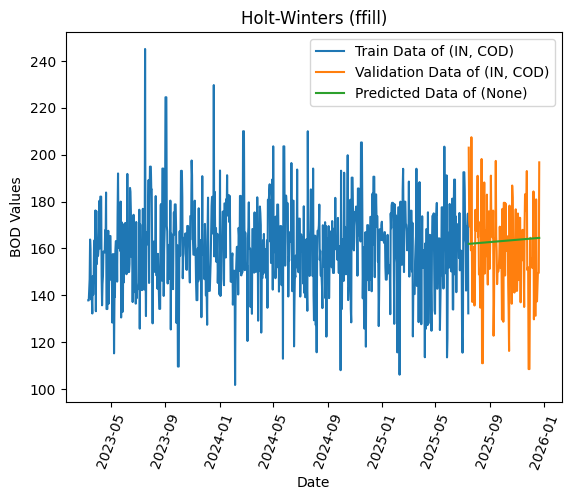

RMSE: 19.864310313174506
MAE: 15.379210867927569
MAPE: 0.1047337697469084
R2 Score: -0.07975246647093615


In [ ]:
model_assessment_plot(ffill_train_target, ffill_val_target, hw_ffill_pred, 'Holt-Winters (ffill)')

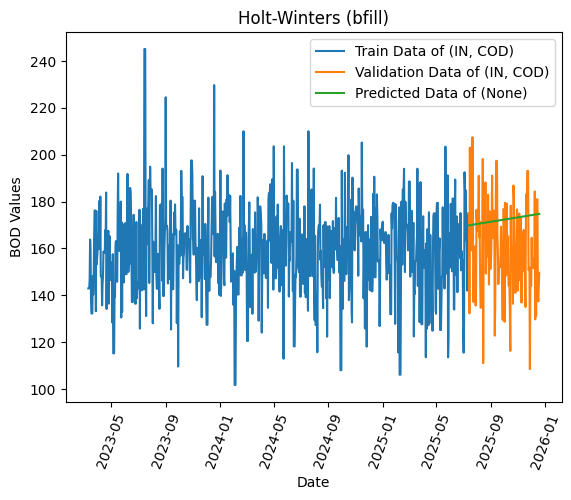

RMSE: 23.404065656492513
MAE: 19.438813629773737
MAPE: 0.13220350690666977
R2 Score: -0.569686944853097


In [ ]:
model_assessment_plot(bfill_train_target, bfill_val_target, hw_bfill_pred, 'Holt-Winters (bfill)')

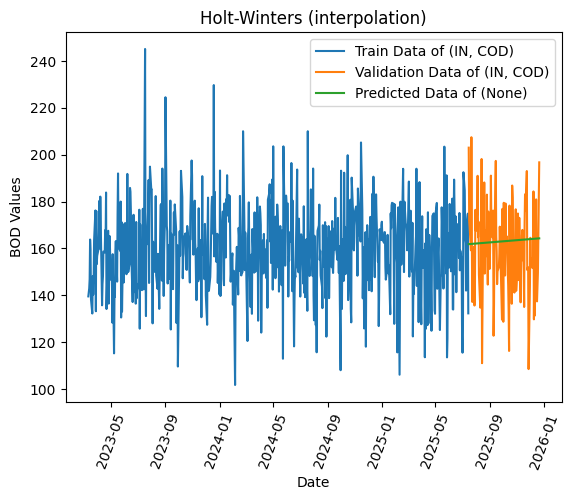

RMSE: 18.464587100614768
MAE: 14.549855843268414
MAPE: 0.09629924427077603
R2 Score: -0.07013385337362954


In [ ]:
model_assessment_plot(interpolation_train_target, interpolation_val_target, hw_interpolation_pred, 'Holt-Winters (interpolation)')

# ARIMA

In [ ]:
# Rechecking Stationary

def check_stationary(df):

  result = adfuller(df['IN, COD'])

  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print('\t%s: %.3f' % (key, value))

  if result[1] < 0.05:
    print('The p-value falls in the  category of STATIONARY time-series.')
  else:
    print('The time-series data is not stationary.')

In [ ]:
check_stationary(ffill_df)

ADF Statistic: -17.622814
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
The p-value falls in the  category of STATIONARY time-series.


In [ ]:
check_stationary(bfill_df)

ADF Statistic: -18.329538
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
The p-value falls in the  category of STATIONARY time-series.


In [ ]:
check_stationary(interpolation_df)

ADF Statistic: -24.555487
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
The p-value falls in the  category of STATIONARY time-series.


---

Therefore, we can assume that the data do not require seasonal differencing.

---

In [ ]:
# ARIMA MODEL

"""
Based on the seasonal decomposition analysis, the influent COD data
does not exhibit a significant seasonal pattern.
"""


def predict_and_plot_arima(train_df, val_df,imputation_method):

  model_arima = auto_arima(train_df,
                           seasonal = False)

  display(model_arima.summary())

  arima_pred = model_arima.predict(n_periods=len(val_df))

  plt.plot(train_df, label='Train Data')
  plt.plot(val_df, label='Validation Data')
  plt.plot(arima_pred, label= 'Predictions')
  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD')
  plt.title(f'Forecast Plot for ARIMA Model {imputation_method} method')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, arima_pred)
  mae = mean_absolute_error(val_df, arima_pred)
  mape = mean_absolute_percentage_error(val_df, arima_pred)

  print(f"ARIMA {imputation_method} RMSE: {rmse}")
  print(f"ARIMA {imputation_method} MAE: {mae}")
  print(f"ARIMA {imputation_method} MAPE: {mape}")

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -3681.606
Date:                Sat, 25 Jul 2026   AIC                           7373.212
Time:                        07:23:07   BIC                           7396.985
Sample:                    03-11-2023   HQIC                          7382.314
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    111.7879      7.366     15.176      0.000      97.351     126.225
ar.L1          0.2688      0.028      9.577      0.000       0.214       0.324
ar.L2          0.0845      0.032      2.665      0.008       0.022       0.147
ar.L3         -0.0501      0.038     -1.327      0.185      -0.124       0.024
sigma2       312.3863     11.862     26.335      0.000     289.137     335.636
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.15
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                             0.11
Prob(H) (two-sided):                  0.93   Kurtosis:                         4.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

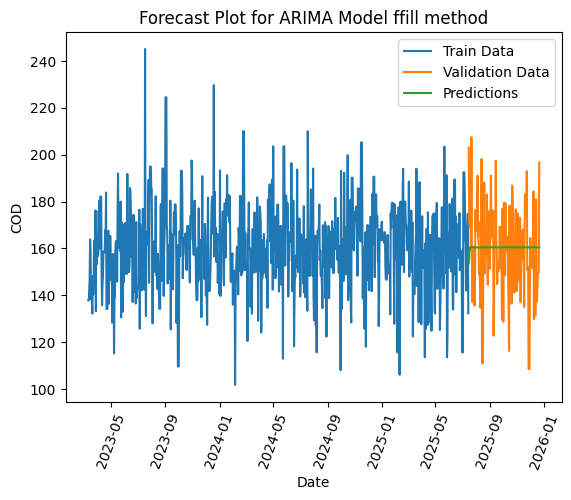

ARIMA ffill RMSE: 19.356104232235722
ARIMA ffill MAE: 15.134246298463623
ARIMA ffill MAPE: 0.10136455559663009


In [ ]:
predict_and_plot_arima(ffill_train_target, ffill_val_target, 'ffill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  855
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -3686.139
Date:                Sat, 25 Jul 2026   AIC                           7380.278
Time:                        07:23:21   BIC                           7399.282
Sample:                    03-11-2023   HQIC                          7387.555
                         - 07-12-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     95.9484      4.851     19.779      0.000      86.440     105.456
ar.L1          0.3139      0.026     12.129      0.000       0.263       0.365
ar.L2          0.0812      0.029      2.771      0.006       0.024       0.139
sigma2       325.2162     12.240     26.571      0.000     301.227     349.205
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                75.67
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                             0.22
Prob(H) (two-sided):                  0.65   Kurtosis:                         4.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

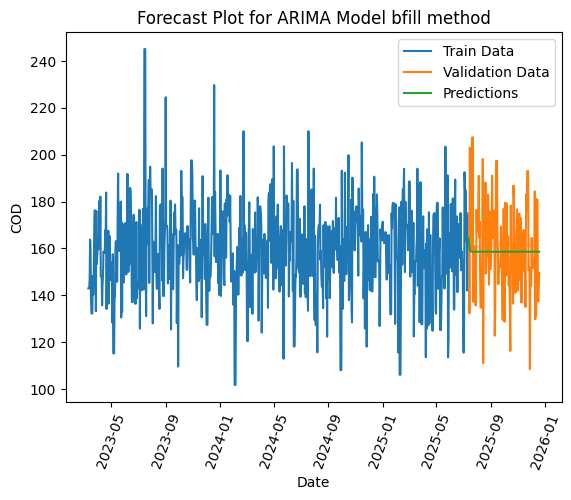

ARIMA bfill RMSE: 18.63871527641592
ARIMA bfill MAE: 14.851191213115618
ARIMA bfill MAPE: 0.09556432771900511


In [ ]:
predict_and_plot_arima(bfill_train_target, bfill_val_target, 'bfill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -3636.014
Date:                Sat, 25 Jul 2026   AIC                           7278.029
Time:                        07:23:29   BIC                           7292.292
Sample:                    03-11-2023   HQIC                          7283.490
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    107.5025      4.078     26.362      0.000      99.510     115.495
ar.L1          0.3261      0.025     12.904      0.000       0.277       0.376
sigma2       280.6842     10.860     25.846      0.000     259.399     301.969
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                52.92
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               1.04   Skew:                             0.15
Prob(H) (two-sided):                  0.72   Kurtosis:                         4.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

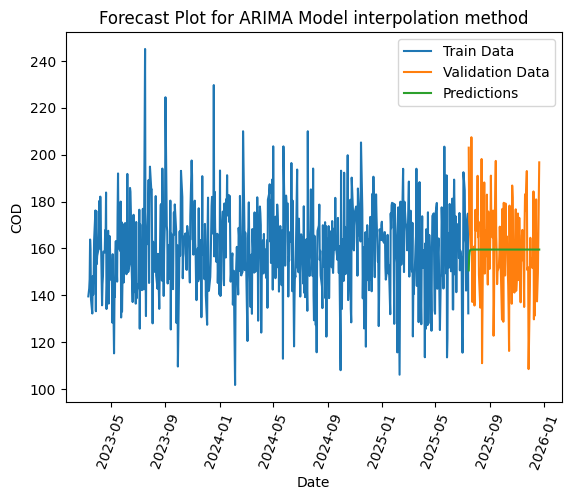

ARIMA interpolation RMSE: 18.029929675134074
ARIMA interpolation MAE: 14.039994138848636
ARIMA interpolation MAPE: 0.09099180754180093


In [ ]:
predict_and_plot_arima(interpolation_train_target, interpolation_val_target, 'interpolation')

# SARIMA

In [ ]:
# SARIMA MODEL

def predict_and_plot_sarima(train_df, val_df,imputation_method):

  model_sarima = auto_arima(train_df,
                            m=7,
                           seasonal = True)

  display(model_sarima.summary())

  sarima_pred = model_sarima.predict(n_periods=len(val_df))

  plt.plot(train_df, label='Train Data')
  plt.plot(val_df, label='Validation Data')
  plt.plot(sarima_pred, label= 'Predictions')
  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD')
  plt.title(f'Forecast Plot for SARIMA Model {imputation_method} method')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, sarima_pred)
  mae = mean_absolute_error(val_df, sarima_pred)
  mape = mean_absolute_percentage_error(val_df, sarima_pred)

  print(f"SARIMA {imputation_method} RMSE: {rmse}")
  print(f"SARIMA {imputation_method} MAE: {mae}")
  print(f"SARIMA {imputation_method} MAPE: {mape}")

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -3681.606
Date:                Sat, 25 Jul 2026   AIC                           7373.212
Time:                        07:24:21   BIC                           7396.985
Sample:                    03-11-2023   HQIC                          7382.314
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    111.7879      7.366     15.176      0.000      97.351     126.225
ar.L1          0.2688      0.028      9.577      0.000       0.214       0.324
ar.L2          0.0845      0.032      2.665      0.008       0.022       0.147
ar.L3         -0.0501      0.038     -1.327      0.185      -0.124       0.024
sigma2       312.3863     11.862     26.335      0.000     289.137     335.636
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                67.15
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                             0.11
Prob(H) (two-sided):                  0.93   Kurtosis:                         4.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

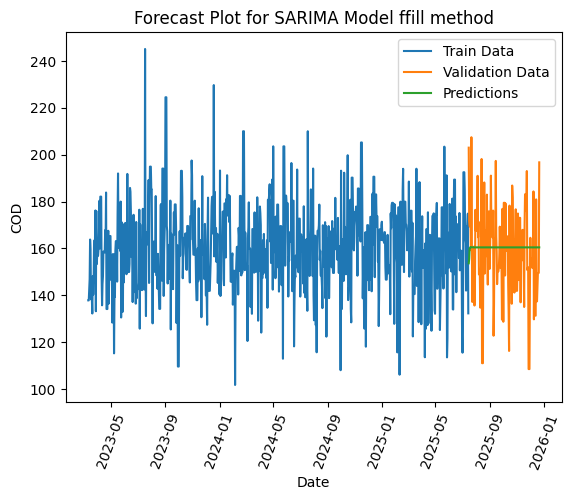

SARIMA ffill RMSE: 19.356104232235722
SARIMA ffill MAE: 15.134246298463623
SARIMA ffill MAPE: 0.10136455559663009


In [ ]:
predict_and_plot_sarima(ffill_train_target, ffill_val_target, 'ffill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  855
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -3686.139
Date:                Sat, 25 Jul 2026   AIC                           7380.278
Time:                        07:24:50   BIC                           7399.282
Sample:                    03-11-2023   HQIC                          7387.555
                         - 07-12-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     95.9484      4.851     19.779      0.000      86.440     105.456
ar.L1          0.3139      0.026     12.129      0.000       0.263       0.365
ar.L2          0.0812      0.029      2.771      0.006       0.024       0.139
sigma2       325.2162     12.240     26.571      0.000     301.227     349.205
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                75.67
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                             0.22
Prob(H) (two-sided):                  0.65   Kurtosis:                         4.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

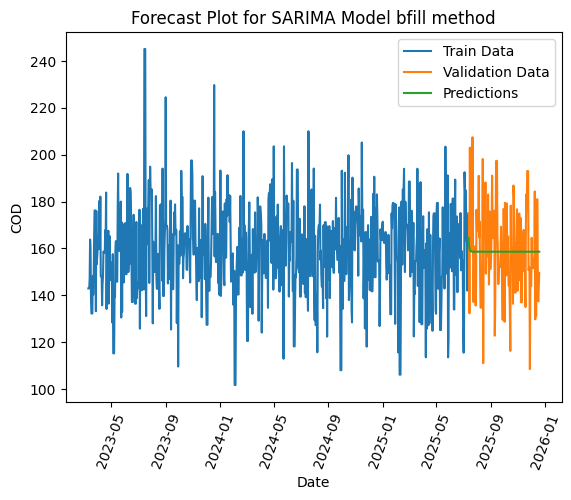

SARIMA bfill RMSE: 18.63871527641592
SARIMA bfill MAE: 14.851191213115618
SARIMA bfill MAPE: 0.09556432771900511


In [ ]:
predict_and_plot_sarima(bfill_train_target, bfill_val_target, 'bfill')

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -3636.014
Date:                Sat, 25 Jul 2026   AIC                           7278.029
Time:                        07:25:06   BIC                           7292.292
Sample:                    03-11-2023   HQIC                          7283.490
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    107.5025      4.078     26.362      0.000      99.510     115.495
ar.L1          0.3261      0.025     12.904      0.000       0.277       0.376
sigma2       280.6842     10.860     25.846      0.000     259.399     301.969
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                52.92
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               1.04   Skew:                             0.15
Prob(H) (two-sided):                  0.72   Kurtosis:                         4.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

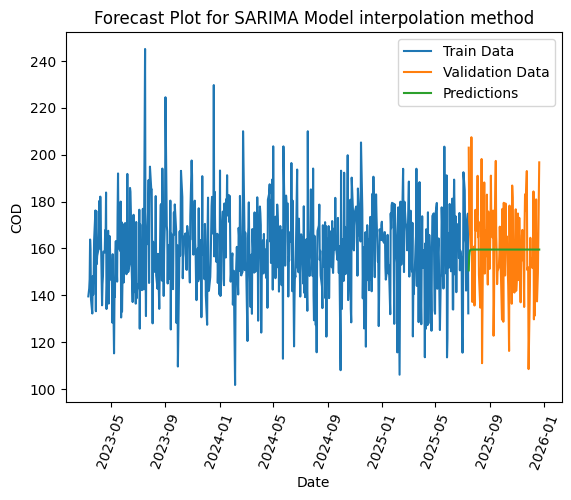

SARIMA interpolation RMSE: 18.029929675134074
SARIMA interpolation MAE: 14.039994138848636
SARIMA interpolation MAPE: 0.09099180754180093


In [ ]:
predict_and_plot_sarima(interpolation_train_target, interpolation_val_target, 'interpolation')

# SARIMAX

## SARIMAX Cross Validation

- Since the seasonal decomposition did not reveal significant seasonal pattern and the automatic model selection procedure identified no seasonaL differencing, or moving average terms (P = D = Q = 0), only the non-seasonal orders (p, d, and q) were evaluated during time-series cross-validation.

In [ ]:
parameter_grid = {
    'p': np.arange(0, 3),
    'd': np.arange(0, 3),
    'q': np.arange(0, 3)
}

grid_cross_val = ParameterGrid(parameter_grid)

def sarimax_cross_validation(train_df, train_df_target, train_df_inputs):

    results = []

    cross_val = RollingForecastCV(
        h=30,
        step=15,
        initial=train_df_target.shape[0] - 320
    )

    for params in grid_cross_val:

        model_cv = PmdarimaARIMA(
            order=(params['p'], params['d'], params['q']),
            seasonal_order=(0, 0, 0, 7)
        )

        cv_score = cross_val_score(
            model_cv,
            y=train_df_target,
            X=train_df_inputs,
            scoring='mean_squared_error',
            cv=cross_val,
            verbose=1
        )

        results.append({
            'p': params['p'],
            'd': params['d'],
            'q': params['q'],
            'MSE': np.mean(cv_score)
        })

    return pd.DataFrame(results)

In [ ]:
sarimax_cross_validation(interpolation_df, interpolation_train_target, interpolation_train_inputs)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximu

,p,d,q,MSE
0,0,0,0,61.188474
1,0,0,1,61.185914
2,0,0,2,61.343698
3,1,0,0,61.192553
4,1,0,1,61.185193
5,1,0,2,61.343088
6,2,0,0,61.378012
7,2,0,1,61.394508
8,2,0,2,61.377381
9,0,1,0,177.340382


- p = 1
- d = 0
- q = 1

In [ ]:
# Final SARIMAX Model

"""
Based on the results of the different models,
the dataset generated using time interpolation
produced the lowest prediction errors.
Therefore, this imputed dataset was selected for developing
the final forecasting model.
"""

model_sarimax_final = PmdarimaARIMA(order = (1,0,1),
                                    seasonal_order = (0,0,0,7)).fit(interpolation_train_target, interpolation_train_inputs)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [ ]:
model_sarimax_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  858
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -2880.971
Date:                Sun, 19 Jul 2026   AIC                           5843.941
Time:                        04:21:53   BIC                           6038.880
Sample:                    03-11-2023   HQIC                          5918.580
                         - 07-15-2025                                         
Covariance Type:                  opg                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                  0.0041        nan        nan        nan         nan         nan
IN, PH                    -0.0983      0.729     -0.135      0.893      -1.528       1.331
IN, NO3-N                  0.7091      0.504      1.406      0.160      -0.279       1.697
IN, Fecal Coli          5.973e-08   6.16e-07      0.097      0.923   -1.15e-06    1.27e-06
IN, BOD                    1.2219      0.069     17.702      0.000       1.087       1.357
IN, Oil & Grease          -0.0615      0.255     -0.241      0.810      -0.562       0.439
IN, PO4-P                  1.1083      0.940      1.179      0.238      -0.734       2.951
IN, Surfactants (MBAS)     2.8576      1.084      2.636      0.008       0.732       4.983
IN, TSS                    0.2622      0.065      4.046      0.000       0.135       0.389
IN, VSS                    0.1121      0.078      1.435      0.151      -0.041       0.265
IN, NH3-N                  0.0118      0.149      0.079      0.937      -0.279       0.303
IN, Flow (m³/hr)           0.0042      0.003      1.472      0.141      -0.001       0.010
lag1_pH                    1.0964      0.777      1.411      0.158      -0.427       2.619
lag1_NO3                  -0.6005      0.508     -1.181      0.238      -1.597       0.396
lag1_Fecal Coli           5.9e-08   6.43e-07      0.092      0.927    -1.2e-06    1.32e-06
lag2_Fecal Coli         1.048e-06   6.49e-07      1.615      0.106   -2.24e-07    2.32e-06
lag1_BOD                  -0.3364      0.124     -2.714      0.007      -0.579      -0.093
lag1_COD                   0.2822      0.083      3.399      0.001       0.119       0.445
lag1_PO4-P                 0.8803      0.941      0.936      0.349      -0.964       2.724
lag1_TSS                  -0.0771      0.068     -1.126      0.260      -0.211       0.057
lag1_VSS                  -0.0791      0.082     -0.961      0.336      -0.240       0.082
lag1_NH3                  -0.0574      0.155     -0.370      0.711      -0.361       0.246
lag1_Flow Rate            -0.0033      0.003     -1.076      0.282      -0.009       0.003
lag2_Flow Rate            -0.0037      0.003     -1.198      0.231      -0.010       0.002
lag3_Flow Rate             0.0037      0.003      1.258      0.208      -0.002       0.009
lag4_Flow Rate            -0.0017      0.003     -0.566      0.571      -0.007       0.004
lag5_Flow Rate             0.0019      0.003      0.620      0.535      -0.004       0.008
lag6_Flow Rate            -0.0024      0.003     -0.789      0.430      -0.008       0.004
lag7_Flow Rate             0.0038      0.003      1.240      0.215      -0.002       0.010
lag10_Flow Rate           -0.0027      0.003     -0.967      0.334      -0.008       0.003
Day                        0.0111      0.028      0.398      0.690      -0.044       0.066
Month                      0.0942      0.096      0.984      0.325      -0.093       0.282
Year                       0.0041      0.005      0.906 

In [ ]:
# Prediction

final_prediction_COD = model_sarimax_final.predict(n_periods = len(interpolation_val_target),
                                                   X = interpolation_val_inputs)

final_prediction_COD = final_prediction_COD.rename('SARIMAX, COD')

In [ ]:
# Generate predictions for the test set
test_prediction_COD = model_sarimax_final.predict(n_periods = len(interpolation_test_target),
                                                 X = interpolation_test_inputs)

test_prediction_COD = test_prediction_COD.rename('SARIMAX, COD')

In [ ]:
# Plotting

import matplotlib.ticker as mticker

def model_assessment_plot(train_df, val_df, pred_df, chart_title):

  plt.plot(train_df, label=f'Train Data of ({train_df.name})')
  plt.plot(val_df, label=f'Validation Data of ({val_df.name})')
  plt.plot(pred_df, label=f'Predicted Value')

  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD Values')
  plt.title(f'{chart_title}')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, pred_df)
  mae = mean_absolute_error(val_df, pred_df)
  mape = mean_absolute_percentage_error(val_df, pred_df)

  print(f"{chart_title} RMSE: {rmse}")
  print(f"{chart_title} MAE: {mae}")
  print(f"{chart_title} MAPE: {mape}")

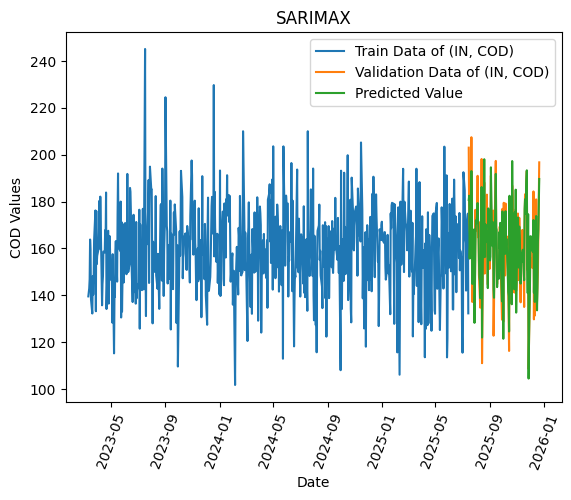

SARIMAX RMSE: 7.333415278789481
SARIMAX MAE: 5.818756543603186
SARIMAX MAPE: 0.03691148978034707


In [ ]:
model_assessment_plot(interpolation_train_target,
                      interpolation_val_target,
                      final_prediction_COD,
                      'SARIMAX'
)

## Residual Analysis

In [ ]:
# Residual Analysis

def residual_analysis(val_df, pred_df):

  residuals = val_df - pred_df

  # Create a residual plot

  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=pred_df, y=residuals, alpha=0.6)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.xlabel('Predicted Values')
  plt.ylabel('Residuals')
  plt.title('Residual Plot')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

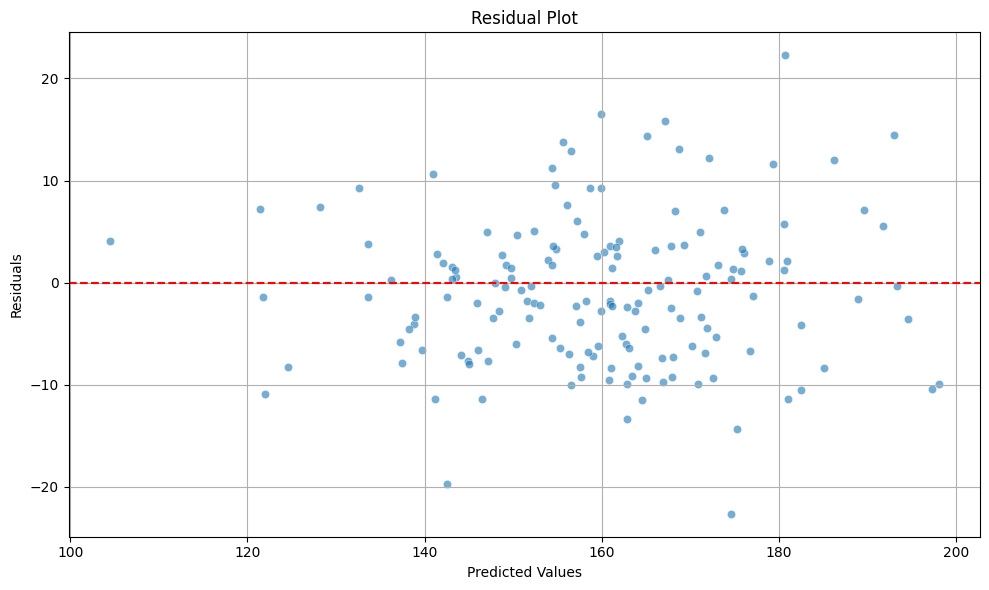

In [ ]:
residual_analysis(interpolation_val_target,
                  final_prediction_COD
)

## R2 Score

In [ ]:
# Calculate the R2 score
r2 = r2_score(interpolation_val_target, final_prediction_COD)
print(f'The R2 score for the SARIMAX Model is: {r2:.4f}')

The R2 score for the SARIMAX Model is: 0.8312
